In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


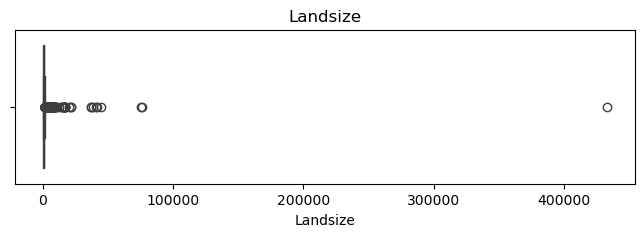

In [155]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='Landsize')
plt.title('Landsize')
plt.show()

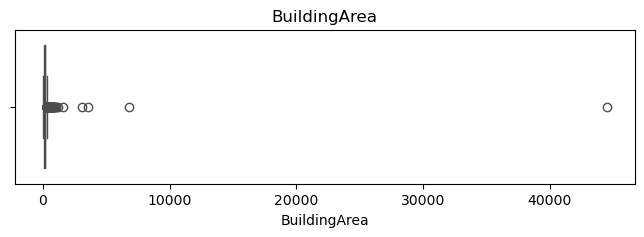

In [134]:
# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='BuildingArea', color='orange')
plt.title('BuildingArea')
plt.show()

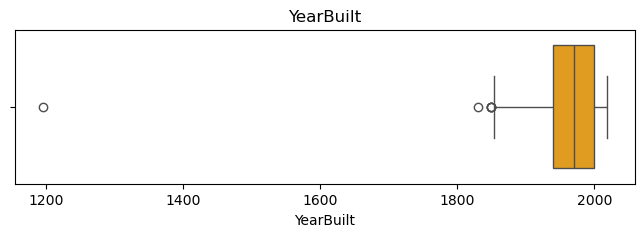

In [135]:
# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='YearBuilt', color='orange')
plt.title('YearBuilt')
plt.show()

In [156]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [157]:
# Assume missing car spaces mean 0 parking spots available
df['Car'] = df['Car'].fillna(0)

# checks if there is still missing values
car = df['Car'].count()
print(car)

13580


In [158]:
# Drops rows where BuildingArea and YearBuilt are missing
df_clean = df.dropna(subset=['BuildingArea', 'YearBuilt'])

# Remove impossible 0 square metre entries
df_clean = df_clean[df_clean['Landsize'] > 0]
df_clean = df_clean[df_clean['BuildingArea'] > 0]

# Fix the Date data type mismatch so it plots chronologically
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')

In [159]:
print("Check")
print("Number of properties with 0 Landsize left:", (df_clean['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df_clean['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df_clean['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df_clean))

Check
Number of properties with 0 Landsize left: 0
Number of properties with 0 Building area left: 0
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 5826


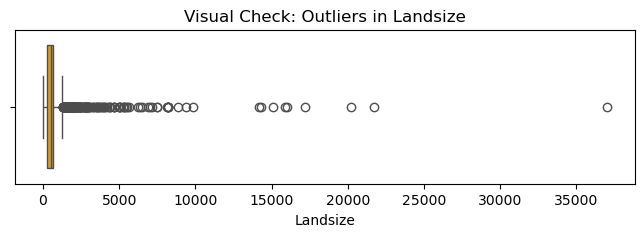

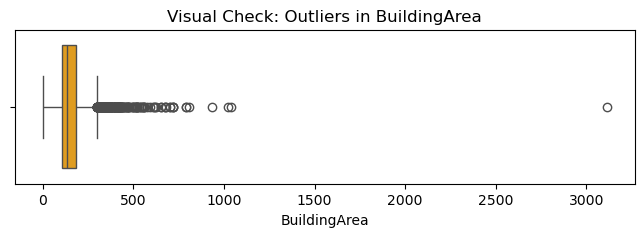

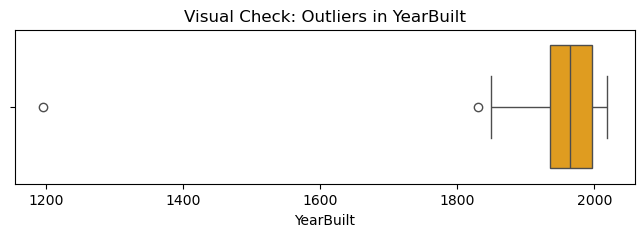

In [160]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [161]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [162]:
# --- Clean Landsize ---
Q1_land = df_clean['Landsize'].quantile(0.25)
Q3_land = df_clean['Landsize'].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df_clean = df_clean[(df_clean['Landsize'] >= lower_land) & (df_clean['Landsize'] <= upper_land)]

# --- Clean BuildingArea ---
Q1_build = df_clean['BuildingArea'].quantile(0.25)
Q3_build = df_clean['BuildingArea'].quantile(0.75)
IQR_build = Q3_build - Q1_build
lower_build = Q1_build - 1.5 * IQR_build
upper_build = Q3_build + 1.5 * IQR_build
df_clean = df_clean[(df_clean['BuildingArea'] >= lower_build) & (df_clean['BuildingArea'] <= upper_build)]

# --- Clean YearBuilt ---
Q1_year = df_clean['YearBuilt'].quantile(0.25)
Q3_year = df_clean['YearBuilt'].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_year = Q1_year - 1.5 * IQR_year
upper_year = Q3_year + 1.5 * IQR_year
df_clean = df_clean[(df_clean['YearBuilt'] >= lower_year) & (df_clean['YearBuilt'] <= upper_year)]

print("Data successfully cleaned! Total rows remaining:", len(df_clean))

Data successfully cleaned! Total rows remaining: 6377


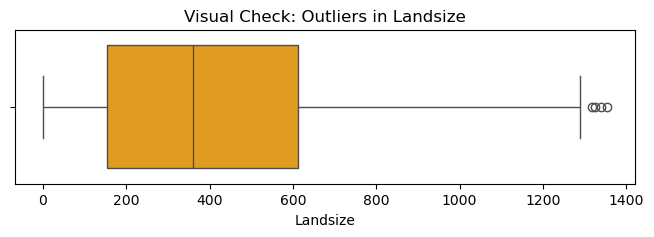

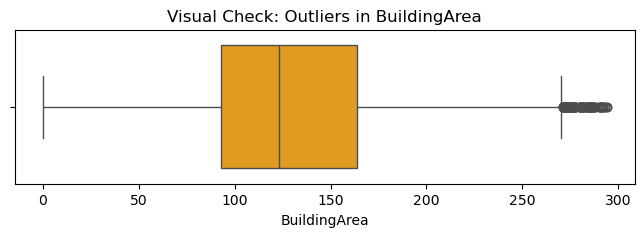

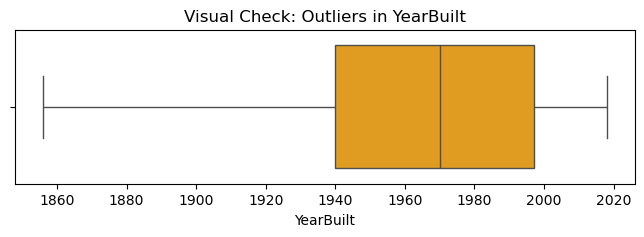

In [163]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [151]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [165]:
# 1. Remove the last remaining Landsize dots above the whisker
df_clean = df_clean[df_clean['Landsize'] <= 1280]

# 2. Remove the last remaining BuildingArea dots above the whisker
df_clean = df_clean[df_clean['BuildingArea'] <= 260]

print("Final manual trim complete! Remaining rows:", len(df_clean))


Final manual trim complete! Remaining rows: 6194


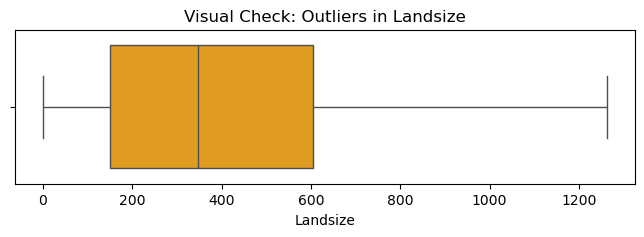

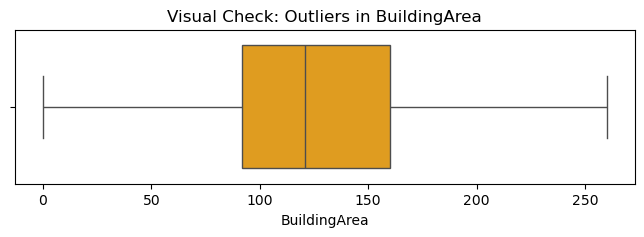

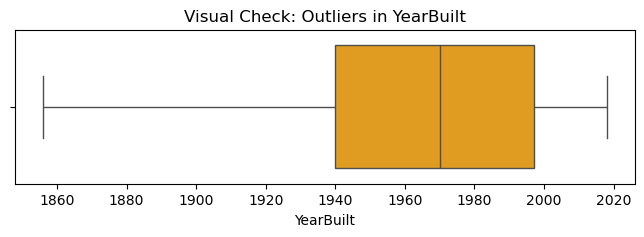

In [166]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

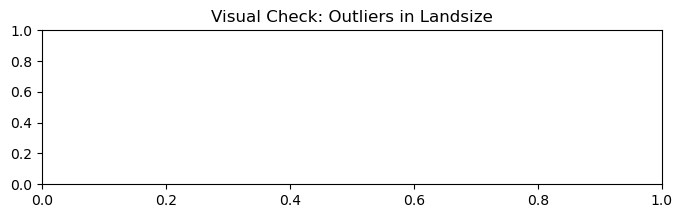

In [18]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

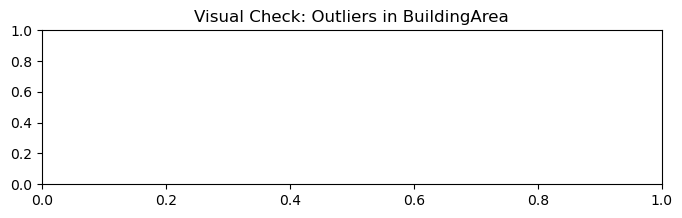

In [15]:
# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

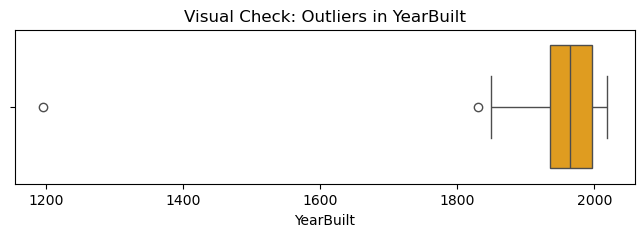

In [10]:
# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [77]:
df_clean.to_csv('melb_housing_cleaned.csv', index=False)
print(df_clean.shape)

(5255, 21)


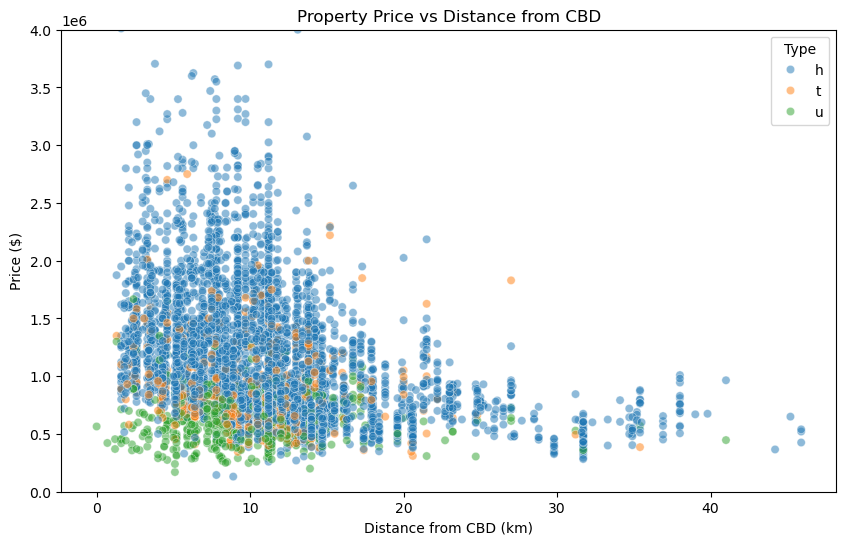

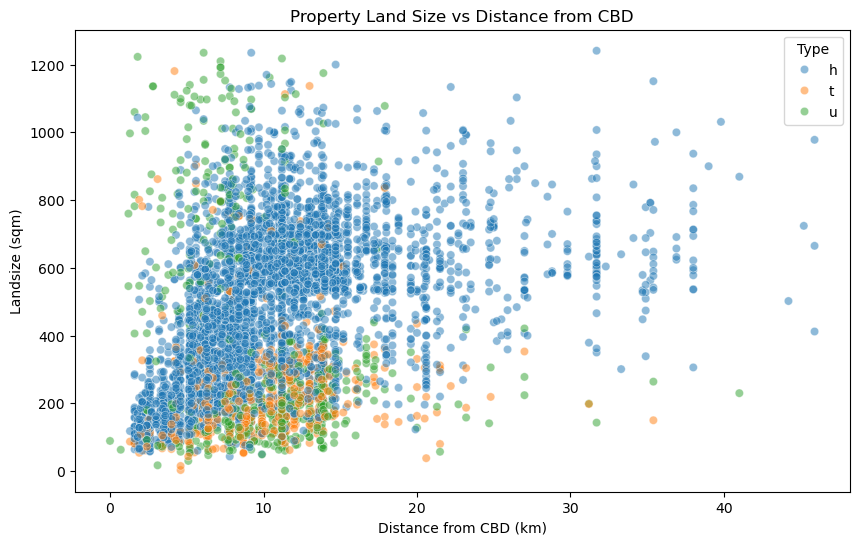

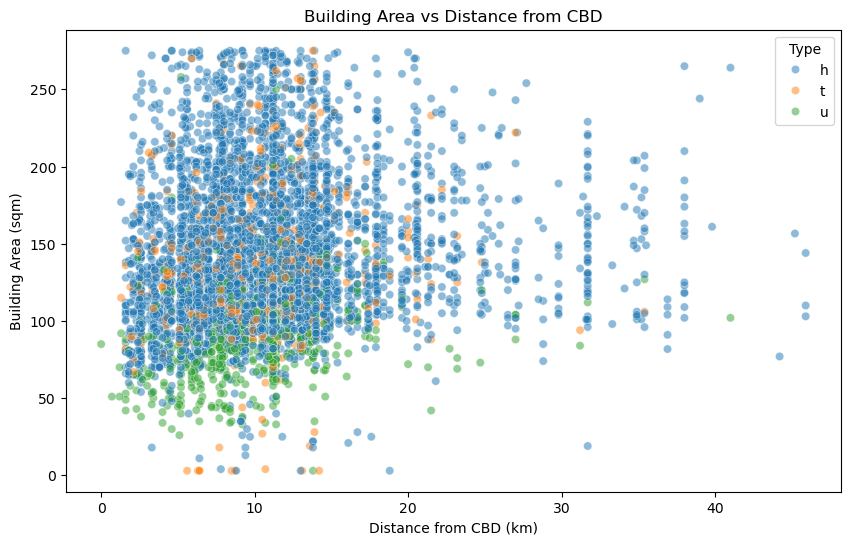

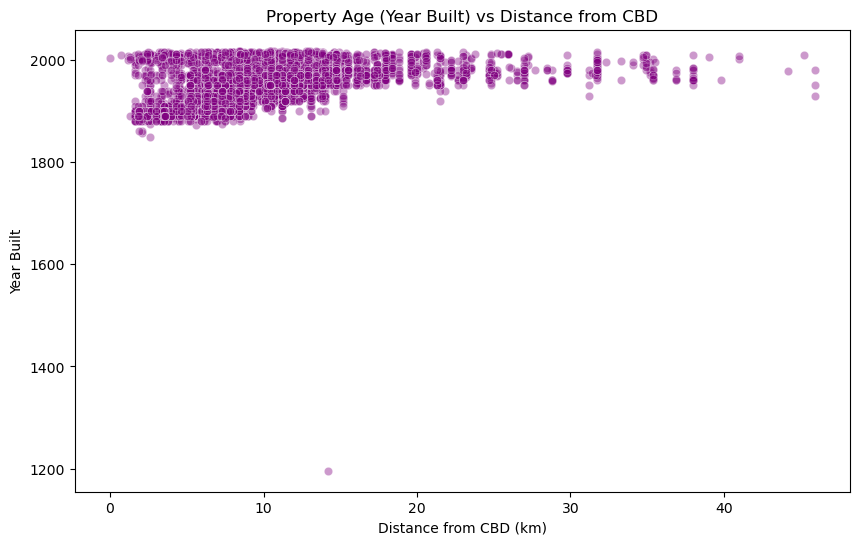

C:\Users\User\AppData\Local\Temp\ipykernel_4808\512482523.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Rooms', y='Distance', palette='Set2')


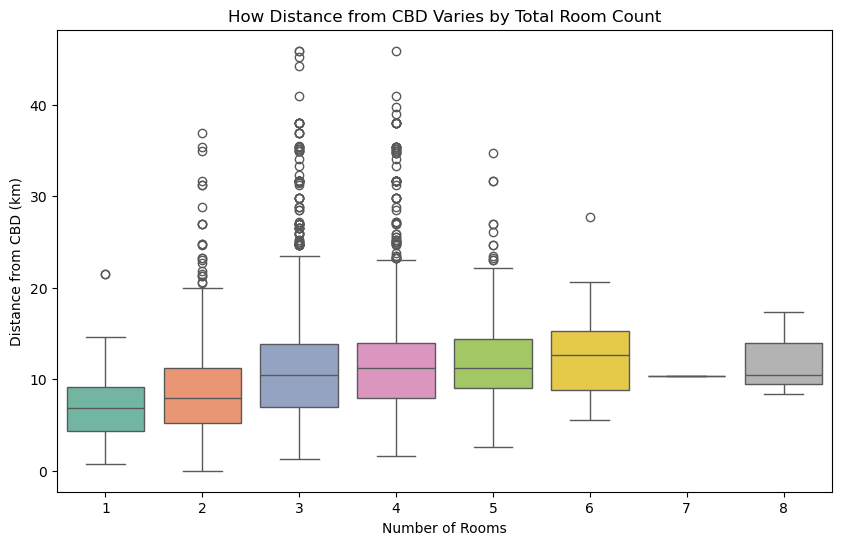

C:\Users\User\AppData\Local\Temp\ipykernel_4808\512482523.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Car', y='Distance', palette='Set2')


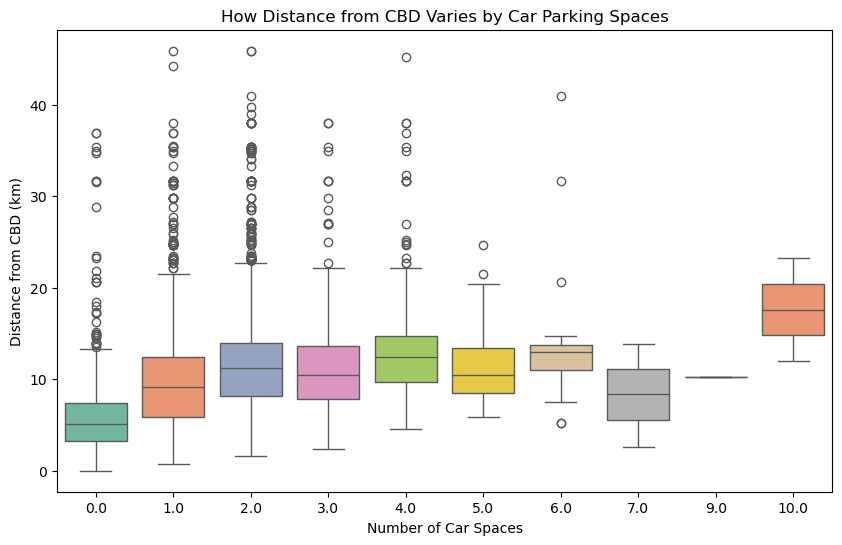

C:\Users\User\AppData\Local\Temp\ipykernel_4808\512482523.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Bathroom', y='Distance', palette='Set2')


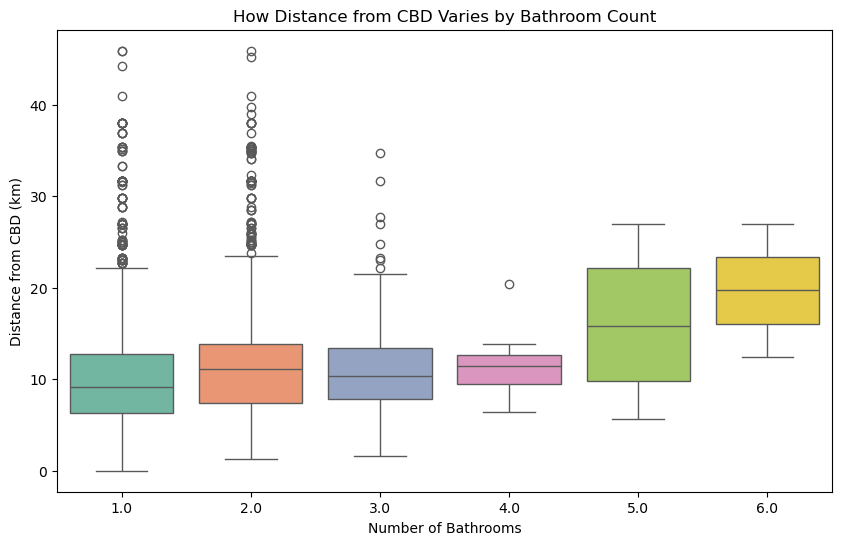

C:\Users\User\AppData\Local\Temp\ipykernel_4808\512482523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Distance', y='Regionname', palette='Pastel1')


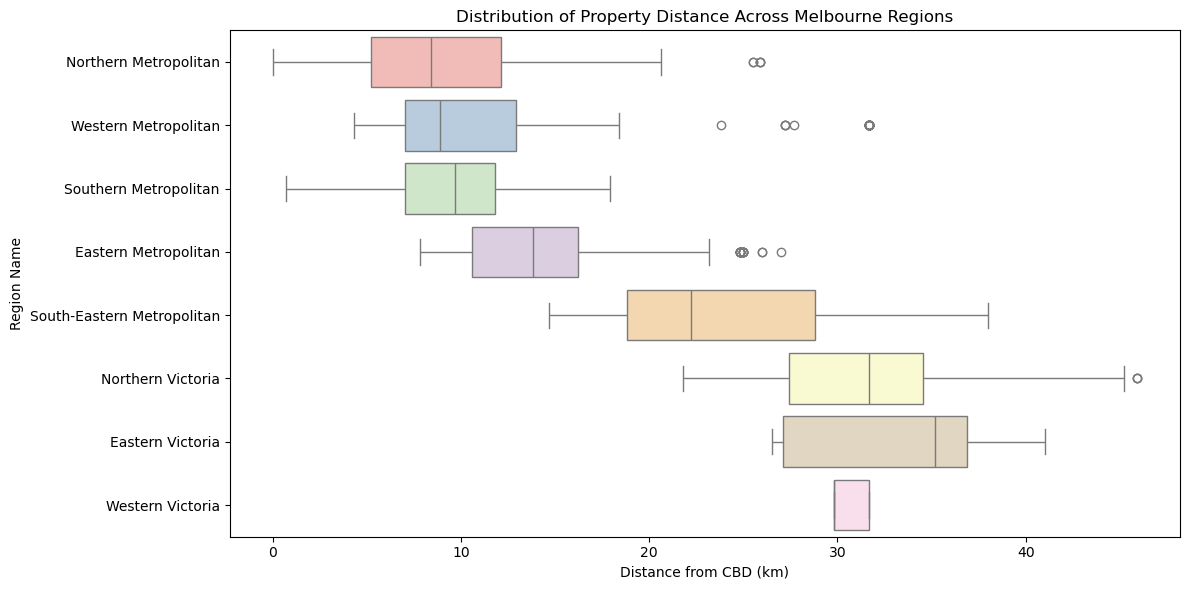

C:\Users\User\AppData\Local\Temp\ipykernel_4808\512482523.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Distance', y='CouncilArea', order=council_order, palette='vlag')


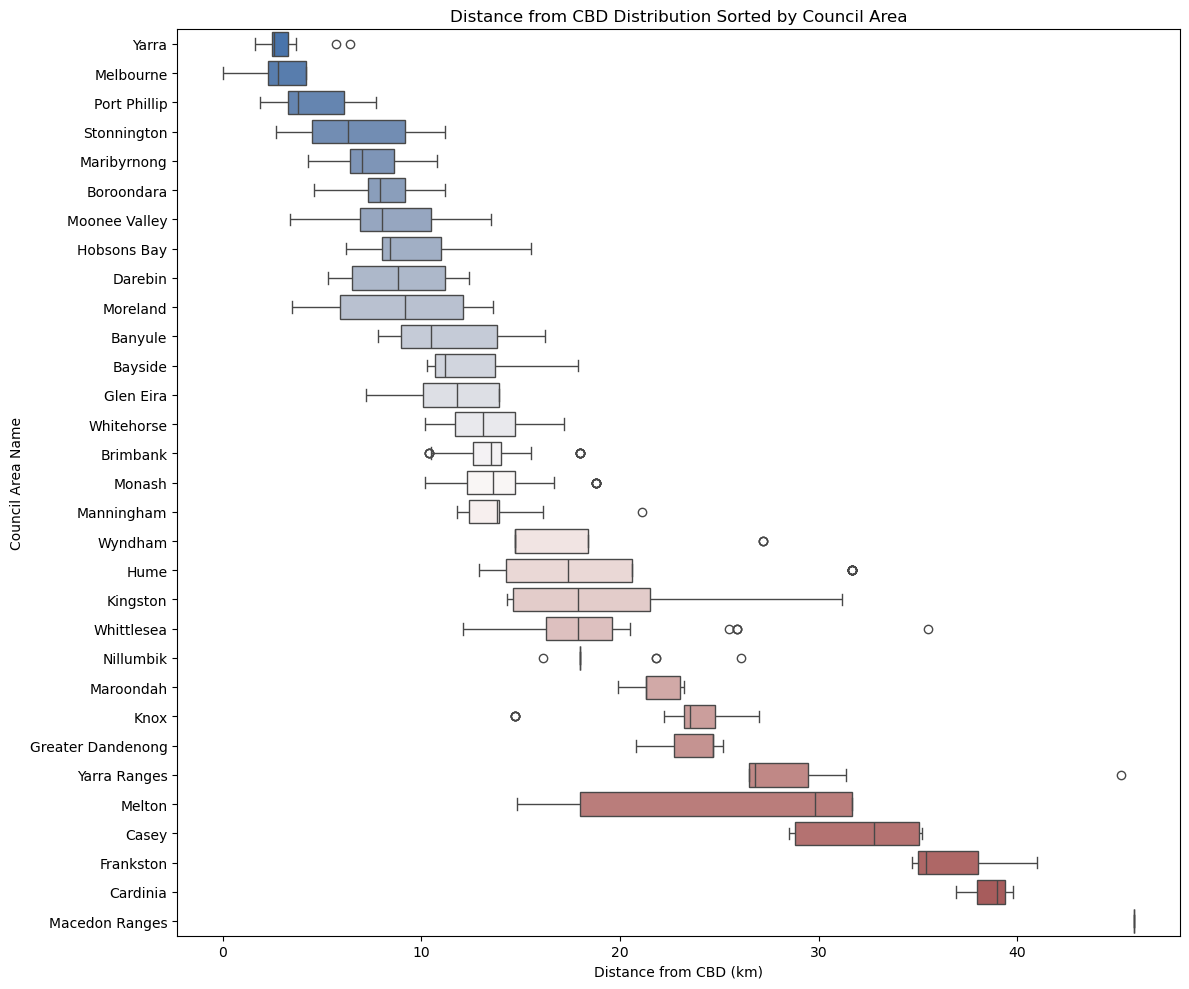

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CATEGORY A: CONTINUOUS MEASUREMENT SCATTER PLOTS
# Use scatter plots for numeric, smooth-scale continuous values.
# ==========================================

# 1. Distance vs Price (Zoomed to $4M to keep main data readable)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Distance', y='Price', hue='Type', alpha=0.5)
plt.ylim(0, 4000000)
plt.title('Property Price vs Distance from CBD')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Price ($)')
plt.show()

# 2. Distance vs Landsize (Cleaned and un-squished)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Distance', y='Landsize', hue='Type', alpha=0.5)
plt.title('Property Land Size vs Distance from CBD')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Landsize (sqm)')
plt.show()

# 3. Distance vs BuildingArea (Cleaned and un-squished)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Distance', y='BuildingArea', hue='Type', alpha=0.5)
plt.title('Building Area vs Distance from CBD')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Building Area (sqm)')
plt.show()

# 4. Distance vs YearBuilt (Property Age Trends)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Distance', y='YearBuilt', alpha=0.4, color='purple')
plt.title('Property Age (Year Built) vs Distance from CBD')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Year Built')
plt.show()


# ==========================================
# CATEGORY B: STRUCTURAL DISCRETE COUNT BOXPLOTS
# Use boxplots when comparing Distance against integer counts (like rooms/cars).
# ==========================================

# 5. Distance vs Total Rooms
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Rooms', y='Distance', palette='Set2')
plt.title('How Distance from CBD Varies by Total Room Count')
plt.xlabel('Number of Rooms')
plt.ylabel('Distance from CBD (km)')
plt.show()

# 6. Distance vs Car Spaces
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Car', y='Distance', palette='Set2')
plt.title('How Distance from CBD Varies by Car Parking Spaces')
plt.xlabel('Number of Car Spaces')
plt.ylabel('Distance from CBD (km)')
plt.show()

# 7. Distance vs Bathroom Count
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Bathroom', y='Distance', palette='Set2')
plt.title('How Distance from CBD Varies by Bathroom Count')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Distance from CBD (km)')
plt.show()


# ==========================================
# CATEGORY C: GEOGRAPHIC & LOCATION CATEGORIES
# Use horizontal boxplots to fit long regional/council text names cleanly.
# ==========================================

# 8. Distance vs Region Name
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='Distance', y='Regionname', palette='Pastel1')
plt.title('Distribution of Property Distance Across Melbourne Regions')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Region Name')
plt.tight_layout()
plt.show()

# 9. Distance vs Council Area
plt.figure(figsize=(12, 10))
# Order councils by their median distance from the CBD so the chart looks organized
council_order = df_clean.groupby('CouncilArea')['Distance'].median().sort_values().index

sns.boxplot(data=df_clean, x='Distance', y='CouncilArea', order=council_order, palette='vlag')
plt.title('Distance from CBD Distribution Sorted by Council Area')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Council Area Name')
plt.tight_layout()
plt.show()
